# 93 호선·군집 분할 검토 + 요일유형 시차 피처 — 결과 노트북

수치 원본은 `RESULTS.md`. 이 노트북은 `compare_split.py --save-results`가 저장한 표를 **출력 그대로 보며 설명**하기
위한 것이라 출력을 남긴 채 커밋한다. 다시 계산하지 않는다.

| 절 | 질문 | 판정 기준(미리 고정) |
| --- | --- | --- |
| 1 | 호선별·6호선 분리·군집별로 fit을 나누면 전역보다 나은가 | 전체 RMSE·MAE 둘 다 개선 + 어느 호선도 2%p 이상 악화 없음. 1%p 미만이면 나누지 않음 |
| 2 | "같은 요일유형 직전 날" 시차(B′)가 주말·공휴일을 살리나 | 일요일·휴일 RMSE 개선율 +3%p 이상, 평일 비악화 |
| 3 | 1호선은 서울역(150) 하나에 끌려가나 | 참고 실험 — 채택 후보 아님 |
| 4 | 방향별 배율표가 방향 오차를 충분히 잡나(실험 D) | 서술 판정 |

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name != "AI":
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "app").is_dir() and (cand / "DATA_ENGINE").is_dir():
            os.chdir(cand)
            break
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle as fs
from DATA_ENGINE.eda import report_figures as rf

fs.apply(inline=True)
pd.set_option("display.width", 180)
inp = rf.Inputs()
res = pd.read_parquet("data/CROWD/interim/validation/split_results.parquet")
print(res["run"].unique(), "| k =", res["k"].iloc[0])

<ArrowStringArray>
['global', 'line', 'line6', 'cluster', 'cluster_feat', 'sameday', 'd1sd', 'global_no150', 'line1_no150']
Length: 9, dtype: str | k = 4


## 1. 전체 — 실행별 lookup 대비 개선율

In [2]:
tot = res[res["axis"] == "전체"].pivot_table(index="run", columns="target", values=["RMSE_개선율_%", "MAE_개선율_%"])
tot.columns = [f"{m}_{t}" for m, t in tot.columns]
order = [r for r in ["global", "line", "line6", "cluster", "cluster_feat", "sameday", "d1sd", "global_no150", "line1_no150"] if r in tot.index]
tot = tot.loc[order]
g = tot.loc["global"]
delta = (tot - g).round(2).add_prefix("Δ")
pd.concat([tot.round(2), delta[["ΔRMSE_개선율_%_boarding", "ΔMAE_개선율_%_boarding"]]], axis=1)

,MAE_개선율_%_alighting,MAE_개선율_%_boarding,RMSE_개선율_%_alighting,RMSE_개선율_%_boarding,ΔRMSE_개선율_%_boarding,ΔMAE_개선율_%_boarding
run,,,,,,
global,27.11,28.23,24.10,22.01,0.00,0.00
line,26.89,28.27,23.26,22.12,0.11,0.04
line6,27.16,28.35,24.11,22.22,0.21,0.12
cluster,27.30,28.59,24.37,22.48,0.47,0.36
cluster_feat,27.13,28.20,24.20,22.03,0.02,-0.03
sameday,24.93,25.68,22.22,19.64,-2.37,-2.55
d1sd,28.42,29.56,25.36,23.38,1.37,1.33
global_no150,26.52,27.74,22.92,20.86,-1.15,-0.49
line1_no150,26.50,27.68,22.84,20.78,-1.23,-0.55


## 2. 호선별 — 전역 vs 분할 (승차 RMSE 개선율)

C:\Users\SSAFY\workspace\S15P21A104\AI\DATA_ENGINE\eda\report_figures.py:1084: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()


C:\Users\SSAFY\miniforge3\envs\SUMGIL\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


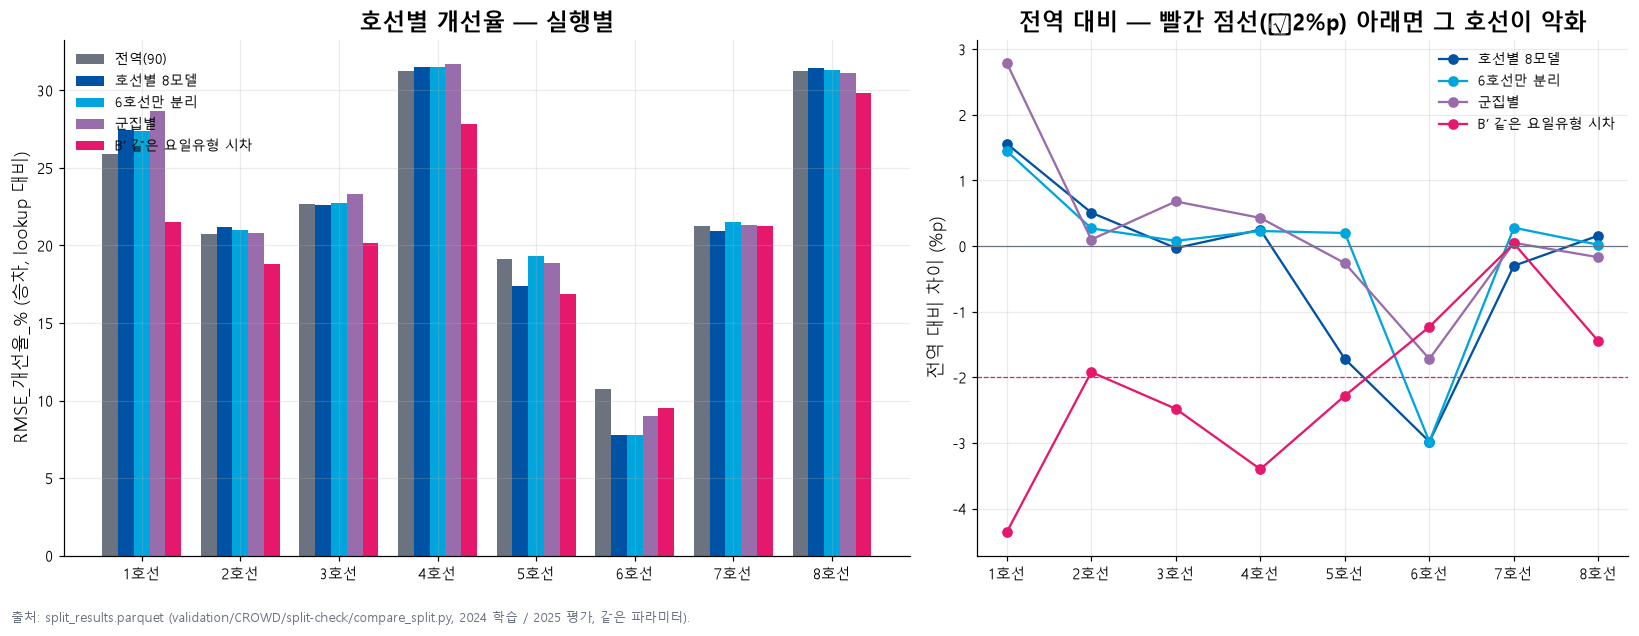

In [3]:
rf.fig_split_by_line(inp);   # runs=("global", "line", "line6", "cluster") 로 바꿔 볼 수 있다

In [4]:
piv = res[(res["axis"] == "line") & (res["target"] == "boarding")].pivot_table(index="group", columns="run", values="RMSE_개선율_%")
piv = piv.reindex(rf.LINE_ORDER)
for c in piv.columns:
    if c != "global":
        piv[f"Δ{c}"] = (piv[c] - piv["global"]).round(2)
piv[[c for c in piv.columns if c.startswith("Δ")]].round(2)

run,Δcluster,Δcluster_feat,Δd1sd,Δglobal_no150,Δline,Δline1_no150,Δline6,Δsameday
group,,,,,,,,
1호선,2.79,-0.04,1.00,-10.39,1.56,-13.64,1.45,-4.36
2호선,0.10,0.11,1.69,0.16,0.51,0.27,0.27,-1.92
3호선,0.68,0.07,1.09,0.07,-0.03,0.21,0.08,-2.48
4호선,0.43,-0.04,1.83,-0.15,0.25,-0.23,0.23,-3.40
5호선,-0.26,-0.02,1.11,-0.46,-1.72,0.06,0.20,-2.28
6호선,-1.72,-0.32,0.31,-0.13,-2.98,0.01,-2.98,-1.23
7호선,0.05,0.03,1.69,0.06,-0.30,-0.12,0.28,0.04
8호선,-0.17,-0.04,1.80,0.06,0.16,-0.04,0.02,-1.45


## 3. 요일유형별 — B′(같은 요일유형 직전 날 시차)의 효과는 주말·휴일에서만 나와야 한다

In [5]:
dt = res[(res["axis"] == "day_type") & (res["target"] == "boarding")].pivot_table(index="group", columns="run", values="RMSE_개선율_%")
dt = dt.reindex(["평일", "토요일", "일요일", "휴일"])
cols = [c for c in ["global", "sameday", "d1sd"] if c in dt.columns]
out = dt[cols].copy()
for c in cols[1:]:
    out[f"Δ{c}"] = (dt[c] - dt["global"]).round(2)
out.round(2)

run,global,sameday,d1sd,Δsameday,Δd1sd
group,,,,,
평일,26.16,24.62,27.66,-1.54,1.50
토요일,14.82,13.72,15.48,-1.10,0.66
일요일,18.80,12.89,19.04,-5.91,0.24
휴일,15.74,10.33,19.37,-5.41,3.63


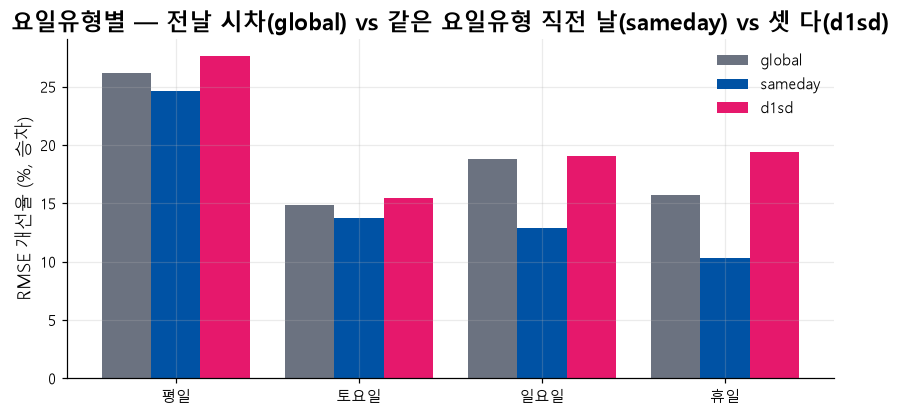

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(out.index))
for i, c in enumerate(cols):
    ax.bar(x + (i - 1) * 0.27, out[c], width=0.27, label=c, color=[fs.COLOR_BASELINE, fs.COLOR_MODEL, fs.COLOR_ACCENT][i])
ax.set_xticks(x); ax.set_xticklabels(out.index)
ax.set_ylabel("RMSE 개선율 (%, 승차)"); ax.legend(frameon=False)
ax.set_title("요일유형별 — 전날 시차(global) vs 같은 요일유형 직전 날(sameday) vs 셋 다(d1sd)")
plt.show()

## 4. 방향 진단(실험 D) — 상/하선 분할 대신

학습 타깃(승하차)에는 방향이 없어 상/하선별 모델은 만들 수 없다. 방향은 88 배율표가 담당한다. 그래서 "방향별 배율표가
방향 차이를 충분히 잡는가"를 배율표 자체로 진단한다(새 학습 없음). 수치는 `RESULTS.md` 4절.

In [7]:
cal = inp.calibration
c = cal[(cal["line"] != "9호선") & cal["ratio"].notna() & (cal["raw_mean"] > 20)]
two = c.groupby(["line", "station_no", "day_type", "time_slot"]).filter(lambda d: d["direction"].nunique() == 2)
w = two.sort_values("direction").groupby(["line", "station_no", "day_type", "time_slot"])["ratio"].agg(["first", "last"])
w["rel"] = (w["first"] - w["last"]).abs() / w.mean(axis=1)
d = w.groupby("line")["rel"].agg(중앙값="median", p75=lambda x: x.quantile(0.75), 절반초과비율=lambda x: (x > 0.5).mean()).round(3)
corr = c.groupby(["line", "direction"]).apply(lambda g: np.corrcoef(g["raw_mean"], g["congestion_pct"])[0, 1]).round(3).unstack()
pd.concat([d, corr], axis=1)

,중앙값,p75,절반초과비율,내선,상선,외선,하선
line,,,,,,,
1호선,0.573,1.111,0.553,NaN,0.644,NaN,0.446
2호선,0.175,0.311,0.088,0.811,NaN,0.753,NaN
3호선,0.165,0.296,0.104,NaN,0.917,NaN,0.865
4호선,0.212,0.402,0.175,NaN,0.852,NaN,0.832
5호선,0.254,0.461,0.220,NaN,0.620,NaN,0.631
6호선,0.160,0.313,0.104,NaN,0.751,NaN,0.741
7호선,0.275,0.473,0.220,NaN,0.771,NaN,0.747
8호선,0.181,0.420,0.197,NaN,0.731,NaN,0.797


**읽기** — 같은 역·시간대에서 두 방향의 배율은 중앙값 16~27% 차이(1호선만 57%)로, 방향을 하나로 뭉개면 이 크기의
오차가 생긴다 → 방향별 배율표를 유지하는 지금 구조가 맞다. 방향별 raw–실측 상관은 호선 안에서 두 방향이 비슷해
(2호선 0.81/0.75, 3호선 0.92/0.87) 한 방향만 특별히 못 잡는 호선은 없다. 1호선 하선 0.45가 가장 낮고, 이는 절단 구간
(패널에 10역만)이라 재귀식이 기점 재차를 모르는 문제다 — 방향 분할이 아니라 노선 범위 문제.

---
**다음.** 판정과 배포 세트 변경 여부는 `RESULTS.md` 5절. 채택된 것이 있으면 `train.py` 기본 세트/그룹 인자 변경은 별도 커밋.